In [20]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import pysindy as ps

In [21]:
#Modelo real del sistema de Lorenz
def lorenz(t,state,sigma=10, rho=28, beta=8/3):
    x,y,z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

In [22]:
#Genero datos reales de x (que equivale a x1)
dt = 0.01
t_span = (0, 50)
t_eval = np.arange(t_span[0], t_span[1], dt)
x0 = [-8, 7, 27]

sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval)
X_real = sol.y.T
print(f"Forma de la matriz de soluciones reales X_real: {X_real.shape}")

# Medición parcial (solo x) con ruido
np.random.seed(42) # Fijo la semilla para reproducibilidad
y_medido = X_real[:, 0] + np.random.normal(0, 0.05, size=len(t_eval))

Forma de la matriz de soluciones reales X_real: (5000, 3)


In [23]:
#Creamos el espacio de retardos (embedding)
#El teorema de Taken dice que n>2m y en este caso m=3, por lo que n debería ser 7
#Sin embargo, como conozco el modelo de Lorenz (se supone que no), n=3 bastará porque corresponde a las 3 variables del sistema
#Sin embargo, voy a usar n mayor para demostrar la reduccion de dimensionalidad gracias al encoder
n_delays = 15   # Dimensión de incrustación (creamos z1, z2, ...,z15)
tau = 5       # retraso temporal (delay)

#X_delay es H matriz de Hankel del articulo pero traspuesta
r=len(y_medido) - (n_delays - 1) * tau
X_delay = np.zeros((r, n_delays)) 
for i in range(n_delays):
    X_delay[:, i] = y_medido[i * tau : r + i * tau]  #En la columna i, meto los datos de y desde i*tau hasta r+i*tau

print(f"Forma X_delay:{X_delay.shape}")
t_delay = t_eval[0:r] # Vector de tiempo alineado con X_delay

Forma X_delay:(4930, 15)


In [24]:
# Aplicamos SVD estándar sobre X_delay
U, S, Vt = np.linalg.svd(X_delay, full_matrices=False)

r_trunc = 7 

# Up debe ser la base del espacio de retrasos (15 componentes). 
Up = Vt.T[:, :r_trunc]

# X_reducido contiene tus coordenadas limpias y proyectadas.
# Multiplicamos X_delay (muestras x 15) por Up (15 x 7) -> Resultado: (muestras x 7)
X_reducido = X_delay @ Up
print(f"Dimensión de Up (Base de Retrasos): {Up.shape}")  # Debe ser (15, 7)
print(f"Dimensión de X_reducido: {X_reducido.shape}")  # Debe ser (muestras, 7)


Dimensión de Up (Base de Retrasos): (15, 7)
Dimensión de X_reducido: (4930, 7)


In [ ]:
# OPERADOR DE KOOPMAN 
# Separamos en Presente y Futuro usando la matriz reducida de 7 dimensiones
Z_pres = X_reducido[:-1, :]  
Z_fut  = X_reducido[1:, :]   

# Operador K por mínimos cuadrados con la orientación correcta: Z_fut ≈ Z_pres @ K
K_operador = np.linalg.pinv(Z_pres) @ Z_fut 

# Extraemos las Koopman Eigenfunctions usando la diagonalización de la matriz K
lambdas, V_koopman = np.linalg.eig(K_operador)

# Proyectamos al espacio linealizado propio de Koopman (cambio de base)
Z_linealizado = X_reducido @ V_koopman  

print(f"Dimensión de la Matriz del Operador K: {K_operador.shape}")  # Debe ser (7, 7)


--- CONTROL DE COMPONENTES DE KOOPMAN ---
Dimensión de la Matriz del Operador K: (7, 7)


In [26]:
# PREDICCIÓN DEL FUTURO Y RECONSTRUCCIÓN
pasos_prediccion = 500

# Creamos la matriz de predicción en el espacio reducido de 7 columnas
Z_predicho = np.zeros((pasos_prediccion, r_trunc))

# Inicializamos
Z_predicho[0, :] = X_reducido[0, :]

for t in range(1, pasos_prediccion):
    Z_predicho[t, :] = Z_predicho[t-1, :] @ K_operador

# RECONSTRUCCIÓN: De 7 dimensiones volvemos a las 15 originales usando Up.T
X_predicho = Z_predicho @ Up.T 

print(f"Dimensión de la predicción final reconstruida: {X_predicho.shape}")

Dimensión de la predicción final reconstruida: (500, 15)


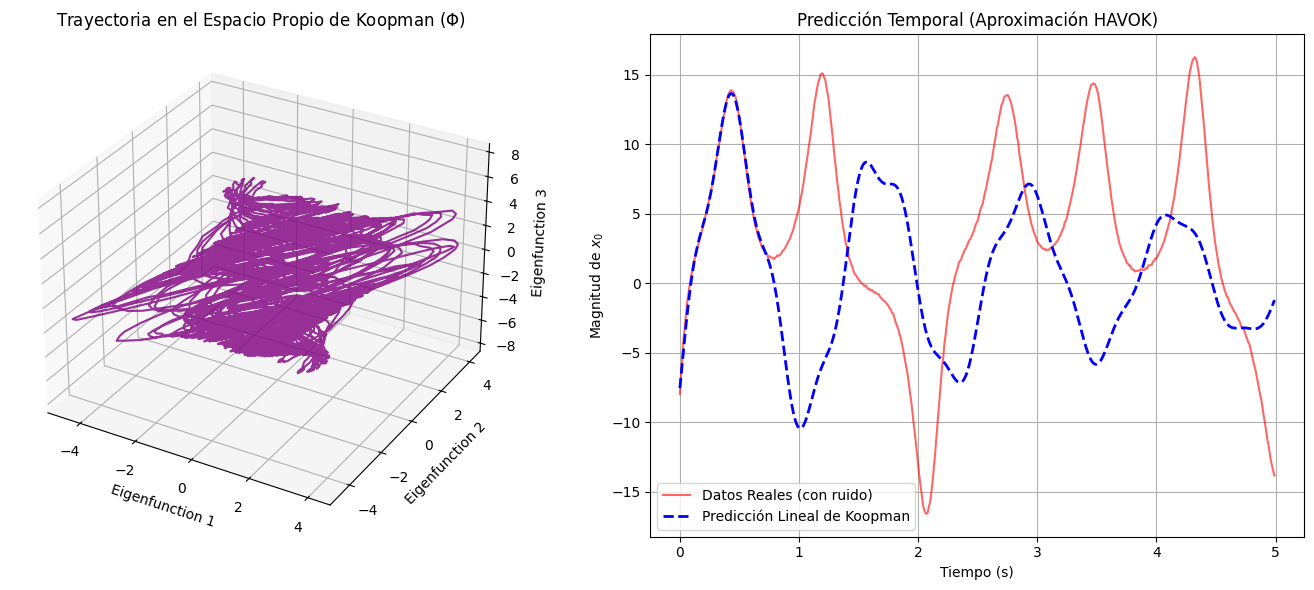

In [ ]:
#Graficos
fig = plt.figure(figsize=(14, 6))

# Subplot 1: Trayectoria en el espacio de Koopman
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(np.real(Z_linealizado[:, 0]), np.real(Z_linealizado[:, 1]), np.real(Z_linealizado[:, 2]), color='purple', alpha=0.8)
ax1.set_title(r"Trayectoria en el Espacio Propio de Koopman ($\Phi$)")
ax1.set_xlabel("Eigenfunction 1")
ax1.set_ylabel("Eigenfunction 2")
ax1.set_zlabel("Eigenfunction 3")
#ALGO FALLA. Ns si es porque el operador de Koopman es infinito o algo mas
#No es que falle: miro el sistema analizando unas mediciones de las verdaderas variables (sen(x),y^5,...)
#por eso no se muestra la mariposa de siempre

# Subplot 2: Evaluación de la Predicción vs Realidad
ax2 = fig.add_subplot(122)
ax2.plot(t_delay[:pasos_prediccion], X_delay[:pasos_prediccion, 0], 'r-', label='Datos Reales (con ruido)', alpha=0.6)
ax2.plot(t_delay[:pasos_prediccion], X_predicho[:, 0], 'b--', label='Predicción Lineal de Koopman', linewidth=2)
ax2.set_title("Predicción Temporal")
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("Magnitud de $x_0$")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()